# MOD510: Project 3

**Deadline: 10. November 2025 (23:59)**


**Group members**

* Simen Sæverud Gåsland

* Nataliia Aksamentova

# Abstract 
**Write here**

# Introduction
**Write here**

# Exercise 1 : Write your own ODE solver

In this exercise, a general solver for systems of ordinary differential equations is implemented. The solver supports three numerical schemes: Euler's method, Runge-Kutta second order (RK2), and Runge-Kutta fourth order (RK4). Each method is tested on $1$-, $2$- and $3$-tank models representing Continuous Stirred-Tank Reactors (CSTRs). The numerical results are compared against analytical solutions to verify accuracy, and to confirm the expected convergence order of the three methods. 

## Part 1

Below we have created a solver that solves a system of ordinary differential equations (ODEs) of the form: 
$$\frac{d \vec{r}}{dt} = \vec{f} \left(\vec{r}, t\right) \text{,}$$

where $\vec{r} = \left[x, y, ...\right]$ and $\vec{f} = \left[f_x \left(\vec{r}, t\right), f_y \left(\vec{r}, t\right), ...\right]$

The solver is designed to handle any generic ODE or systems of ODEs. The user must specify the start time $t_0$, final simulation time $t_f$ and the corresponding initial condition(s) $r_0$.

Four numerical methods are available: 
1. Eulers method
2. Runge-Kutta second order (RK2)
3. Runge-Kutta fourth order (RK4)
4. Numba Runge-Kutta fourth order (Fast RK4)

The last method is not required in this assignment but has been included to demonstrate how Numba can be used to significantly speed up numerical solvers, as introduced in the previous project with the Thomas algorithm. 

Finally, the solver also supports adaptive step size, which adjusts automatically to maintain a local error below a user-defined tolerance $\text{max}_\text{tol}$. 

In [1]:
import numpy as np
import math
import numba_rk4

#Remove Numba warnings to keep notebook clean
import warnings
from numba.core.errors import NumbaExperimentalFeatureWarning
warnings.filterwarnings("ignore", category=NumbaExperimentalFeatureWarning)

class ODESolver:
    '''
    This class solves general ordinary differential equations (ODEs)
    and also systems of ODES using:
        - Euler's method
        - Runge-Kutta 2nd order (RK2)
        - Runge-Kutta 4th order (RK4)
        - A faster RK4 implementation (via numba_rk4)
    Supports both fixed and adaptive step size.
    '''
    def __init__(self, f, t0, tf, h, r0, method = 'rk4', max_tol = 1e-5, adaptive = True, args = ()):
        '''
        Initialize the ODE solver.

        Parameters
        ----------
        f : callable
            Function that defines the ODE system: f(r, t, *args)
        t0 : float
            Initial time
        tf : float
            Final time
        h : float
            Step size
        r0 : list
            Initial condition(s)
        method : str, optional
            Integration method ('euler', 'rk2', 'rk4', 'fast_rk4')
        max_tol : float, optional
            Maximum allowed local error for adaptive step size
        adaptive : bool, optional
            If True, use adaptive step size
        args : tuple, optional
            Extra arguments passed to f
        '''

        #Store parameters
        self.f = f
        self.t0 = t0
        self.tf = tf
        self.h = h
        if adaptive:
            #Allocating a large number  of n's
            self.n = int(1e6)
        else:
            self.n = math.ceil((tf - t0) / h)

        #Allocating for time and solution
        self.t_points = np.zeros(self.n + 2, float)
        self.r0 = np.array(r0, float)

        #Select method from dictionary
        self.method = method
        self.choosen_method = {'euler': self.__euler,
                               'rk2': self.__rk2,
                               'rk4': self.__rk4,
                               'fast_rk4': numba_rk4.solve
                               }[method]

        self.r_points = np.zeros((self.n + 2, len(self.r0)), float)
        self.adaptive = adaptive

        #Selecting step exponent for method
        self.step_exponent = {"euler":1/2, "impeuler":1/3, "rk2":1/3, "rk4":1/5, 'fast_rk4': None}[method]

        self.max_tol = max_tol
        self.args = args

    def __euler(self, t, r, h):
        '''
        Eulers method
        '''
        return r + h * self.f(r, t, *self.args)

    def __rk2(self, t, r, h):
        '''
        Runge-Kutta second order (RK2)
        '''
        k1 = self.f(r, t, *self.args)
        k2 = self.f(r + 0.5 * k1 * h, t + 0.5 * h, *self.args)
        return r + h * k2

    def __rk4(self, t, r, h):
        '''
        Runge-Kutta fourth order (RK4)
        '''
        k1 = h * self.f(r, t, *self.args)
        k2 = h * self.f(r + 0.5 * k1, t + 0.5 * h, *self.args)
        k3 = h * self.f(r + 0.5 * k2, t + 0.5 * h, *self.args)
        k4 = h * self.f(r + k3, t + h, *self.args)
        return r + (k1 + 2 * k2 + 2 * k3 + k4) / 6

    def solve(self):
        '''
        Solves ODEs using users method of choice

        Returns
        ----------
        t_points : array
            Array of time points
        r_points: array
            Array of solution values corresponding to t_points
        '''

        #Initialize
        self.r_points[0] = self.r0
        self.t_points[0] = self.t0

        #If fast RK4 is chosen
        if self.choosen_method == numba_rk4.solve:
            self.t_points, self.r_points = self.choosen_method(
                                            self.f, self.h, self.t0, self.tf,
                                            self.r0, self.t_points, self.r_points,
                                            self.adaptive, self.max_tol, *self.args)
        #If a non Numba method is chosen
        else:
            h = self.h
            t = self.t0
            i = 0

            #Time stepping loop
            while t < self.tf:
                r_i = self.r_points[i]

                if self.adaptive:
                    #Full step
                    r1 = self.choosen_method(t, r_i, h)

                    #First half step
                    r_half = self.choosen_method(t, r_i, h / 2)

                    #Second half step
                    r2 = self.choosen_method(t + h / 2, r_half, h / 2)

                    #Estimate error and adjust step size
                    Err = np.max(np.abs(r2 - r1))
                    Err = max(Err, 1e-14) #Avoid divition by zero
                    h = h * (self.max_tol / Err)**self.step_exponent

                #Avoid stepping beyond tf
                h = min(h, self.tf - t)

                #Advance on step
                self.r = self.choosen_method(t, r_i, h)
                self.r_points[i + 1]= self.r.copy()
                t += h
                self.t_points[i + 1]= t
                i += 1

            #Trim unused preallocated arrays
            self.t_points = self.t_points[:i+1]
            self.r_points = self.r_points[:i+1]

        return self.t_points, self.r_points


## Part 2

Here, we have defined six functions. The first three represent the mass conservation equations for $1$-, $2$- and $3$-tank systems, respectively. The last three functions are the corresponding analytical solutions. The **@njit** decorator above each function makes them compatible with Numba. 

In [2]:
from numba import njit

@njit
def cd_0(r, t, tau = 2.0):
    ''' 1-tank system '''
    n = 1  #Number of tanks
    Cin = 0 #Inlet conentration
    rp = np.zeros(len(r))
    rp[0] = (n/tau)*(Cin - r[0])
    return rp

@njit
def cd_1(r, t, tau = 2.0):
    ''' 2-tank system '''
    n = 2
    Cin = 0
    rp = np.zeros(len(r))
    rp[0] = (n/tau)*(Cin - r[0]) #Tank 1
    rp[1] = (n/tau)*(r[0] - r[1]) #Tank 2
    return rp

@njit
def cd_2(r, t, tau = 2.0):
    ''' 3-tank system '''
    n = 3
    Cin = 0
    rp = np.zeros(len(r))
    rp[0] = (n/tau)*(Cin - r[0]) #Tank 1
    rp[1] = (n/tau)*(r[0] - r[1]) #Tank 2
    rp[2] = (n/tau)*(r[1]- r[2]) #Tank 3
    return rp

@njit
def c_0(t, tau = 2.0):
    ''' Analytical solution for 1-tank system '''
    return np.exp(-t / tau)

@njit
def c_1(t, tau = 2.0):
    ''' Analytical solution for 2-tank system '''
    return (2 * t / tau) * np.exp(-2 * t / tau)

@njit
def c_2(t, tau = 2.0):
    ''' Analytical solution for 2-tank system '''
    return 9* t**2 / (2 * tau**2) * np.exp(-3 * t / tau)

With these functions, we can now test our solver against the analytical solutions. Below, we have created three instances of the **ODESolver**, all using the same parameters except for the specific ODE functions provided. We generate three plots corresponding to the $1$-, $2$- and $3$-tank systems, each solved using the **Fast RK4** solver with adaptive step size.

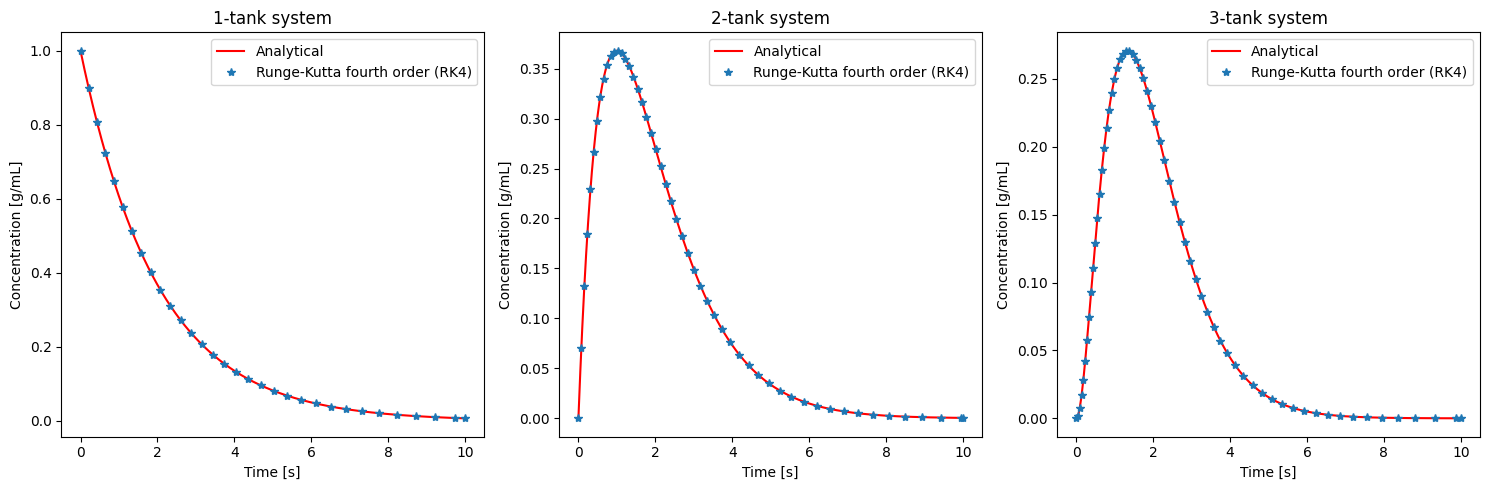

In [3]:
import matplotlib.pyplot as plt

#Time for analytical solution
ta = np.linspace(0, 10, 1000)

#Differential equations and analytical solutions
diff_eqns = [cd_0, cd_1, cd_2]
ana_sols = [c_0, c_1, c_2]

plt.figure(figsize=(15, 5))

for i, diff_eqn in enumerate(diff_eqns):

    #Initial conditions
    r0 = np.zeros(i + 1)
    r0[0] = 1

    #Solve diff equations using Fast RK4
    ode_solver = ODESolver(diff_eqn, 0, 10, 1e-2, r0, 'fast_rk4', 1e-7)
    times, consentrations= ode_solver.solve()

    #Plotting analytical numerical results
    plt.subplot(1, 3, i + 1)
    plt.plot(ta, ana_sols[i](ta), '-',color = 'red', label = "Analytical")
    plt.plot(times, consentrations[:, -1], '*',label = "Runge-Kutta fourth order (RK4)")
    plt.xlabel('Time [s]')
    plt.ylabel('Concentration [g/mL]')
    plt.title(f'{i + 1}-tank system')
    plt.legend()

plt.tight_layout()
plt.show()

From the plots above, we can see that the numerical solutions match the analytical results very well, confirming the correctness of the solver implementation. The adaptive step-size control also behaves as expected. This is particularly noticeable in the $2$- and $3$-tank systems near the peaks, where rapid changes occur and higher accuracy is required. 

Before moving on, we also want to demonstrate the benefits of implementing a Numba-based solver. The first time the **Fast RK4** solver is executed, it will run slightly slower. However, after this first run, the Numba version becomes considerably faster. The performance gain becomes especially significant for large systems.    

In [4]:
import timeit

#Number of tests
number = 10

#Creating instances of ODESolver, one with fast and one with normal RK4
instance_fast = ODESolver(cd_2, 0, 10, 1e-3, [1, 0, 0], 'fast_rk4', adaptive = False)
instance_normal = ODESolver(cd_2, 0, 10, 1e-3, [1, 0, 0], 'rk4', adaptive = False)

#Time it and calculate average on each run
t = timeit.timeit(lambda: instance_fast.solve(), number = number) / number
t2 = timeit.timeit(lambda: instance_normal.solve(), number = number) / number

#Print result
print(f"With Numba: {t}s")
print(f"Without Numba: {t2}s")
print(f"With Numba is {t2/t:.2f} times faster")

With Numba: 0.012114080000901594s
Without Numba: 0.29710545999987514s
With Numba is 24.53 times faster


## Part 3

To analyze the numerical error at $t = 1$, we use the mass conservation equations for the $3$-tank system. We evaluate the error for different time-step sizes $\Delta t$ in the range $\left[0.1, 10^{-4} \right]$. For each numerical method, we expect the following errors [\[$1$\]](#bib): 
$$\text{Euler error} = \mathcal{O}\left( \Delta t\right) \quad \quad \text{RK2 error} = \mathcal{O}\left( \Delta t^2\right) \quad \quad \text{RK4 error} = \mathcal{O}\left( \Delta t^4\right)$$

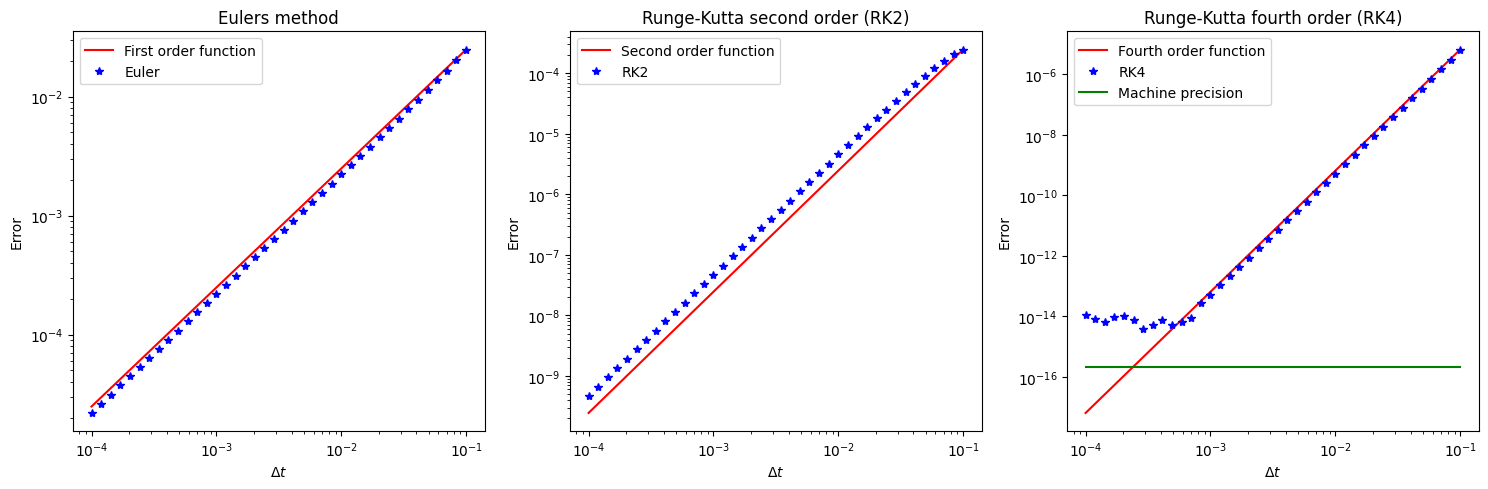

In [5]:
import sys

#Time step sizes
dts = np.logspace(-1, -4, 40)

#Error lists
euler_error = []
rk2_error = []
rk4_error =[]

#Initial condition
r0 = np.array([1, 0, 0])

#Machine precision reference line
machine_precision = np.ones(len(dts)) * sys.float_info.epsilon

for _, dt in enumerate(dts):
    #Creating instences
    ode_solver_euler = ODESolver(f = cd_2, t0 = 0, tf = 1, h = dt, r0 = r0, method = 'euler', adaptive = False)
    ode_solver_rk2 = ODESolver(f = cd_2, t0 = 0, tf = 1, h = dt, r0 = r0, method = 'rk2', adaptive = False)
    ode_solver_rk4 = ODESolver(f = cd_2, t0 = 0, tf = 1, h = dt, r0 = r0, method = 'fast_rk4', adaptive = False)

    #Solving numerically
    t_euler, c_euler = ode_solver_euler.solve()
    t_rk2, c_rk2 = ode_solver_rk2.solve()
    t_rk4, c_rk4 = ode_solver_rk4.solve()

    #Calculate errors
    euler_error.append(np.abs(c_2(t_euler[-1]) - c_euler[-1, -1]))
    rk2_error.append(np.abs(c_2(t_rk2[-1]) - c_rk2[-1, -1]))
    rk4_error.append(np.abs(c_2(t_rk4[-1]) - c_rk4[-1, -1]))

#Scaling reference functions
dt_hat = dts / dts[0]
ref_euler = euler_error[0] * dt_hat
ref_rk2 = rk2_error[0] * dt_hat**2
ref_rk4 = rk4_error[0] * dt_hat**4

#Plotting
plt.figure(figsize=(15, 5))

#Eulers method
plt.subplot(1, 3, 1)
plt.loglog(dts, ref_euler, color = 'red', label = 'First order function')
plt.loglog(dts, euler_error, '*', color = 'blue', label = 'Euler')
plt.ylabel('Error')
plt.xlabel(r'$\Delta t$')
plt.title('Eulers method')
plt.legend()

#Runge-Kutta second order
plt.subplot(1, 3, 2)
plt.loglog(dts, ref_rk2, color = 'red', label = 'Second order function')
plt.loglog(dts, rk2_error, '*', color = 'blue', label = 'RK2')
plt.ylabel('Error')
plt.xlabel(r'$\Delta t$')
plt.title('Runge-Kutta second order (RK2)')
plt.legend()

#Runge-Kutta fourth order
plt.subplot(1, 3, 3)
plt.loglog(dts, ref_rk4, color = 'red', label = 'Fourth order function' )
plt.loglog(dts, rk4_error, '*', color = 'blue', label = 'RK4')
plt.loglog(dts, machine_precision, '-', color = 'green', label = 'Machine precision')
plt.ylabel('Error')
plt.xlabel(r'$\Delta t$')
plt.title('Runge-Kutta fourth order (RK4)')
plt.legend()

plt.tight_layout()
plt.show()

As seen in the plots above, the results match our expectations. Euler's method aligns well with a first-order function, and RK2 shows the expected second-order behavior. For the RK4, we observe an interesting effect: for large values of $\Delta t$, the error follows a fourth-order trend as predicted, but as $\Delta t$ approaches machine precision, rounding error begins to dominate. At this point, the total error can no longer decrease, since numerical precision limits are reached. The same effect would also occur with the Euler's and RK2 methods if we used sufficiently small time steps. 

# Exercise 2: Fit CSTR model to CFD model: Healthy aorta

In this exercise, we use the Continuous Stirred-Tank Reactor (CSTR) model to reproduce the tracer concentration obtained from Computational Fluid Dynamics (CFD) simulations of a healthy aorta. The goal is to tune the model parameters so that the outlet concentration from the $n$-tank system matches the CFD results as closely as possible. We begin by estimating the volumetric flow rate $q$ and then determine $\tau$ and total aortic volume $V_{tot}. Finally, the model is validated by comparing its predictions to CFD data for different injection protocols. 

## Part 1

To find the volumetric injection flow rate $q$, we must solve the following equation: 
$$q = \frac{M_{inj}}{\int_0^\infty C_{out}(t)\text{dt}}$$

Before performing the calculations, we need to ensure that the resulting units are correct. We want $q$ to be expressed in $L/min$, where $M_{inj}$ is given to in grams, and $C_{out}$ is in $g/mL$. Since the integration adds a factor of seconds, we must convert the resulting units from $\frac{mL}{s}$ to $\frac{L}{min}$.

The unit conversion is shown below:
$$\frac{\cancel{g}}{\frac{\cancel{g}}{mL} \cdot s} \quad \Rightarrow \quad \frac{1}{\frac{s}{mL}} \quad \Rightarrow \quad \frac{mL}{s} \quad \Rightarrow \quad \frac{\cancel{mL} \cdot \frac{1 L}{1000 \cancel{mL}}}{\cancel{s} \cdot \frac{1min}{60 \cancel{s}}} \quad \Rightarrow \quad \frac{\frac{1}{1000} L}{\frac{1}{60}min} \quad \Rightarrow \quad \frac{6}{100}\frac{L}{min}$$

Thus, after computing $q$ from the formula, we multiply the result by $\frac{6}{100}$ to obtain the correct units in $\frac{L}{min}$.

The injected mass is given as $M_{inj} = 83.333 g$, and the outlet concentration $C_{out}$ is taken from CFD data. Below, we import the CFD dataset for the healthy aorta using the **rect 1s** injection protocol and integrate the data using NumPy’s **trapezoid** function, which performs numerical integration via the trapezoidal rule [\[$2$\]](#bib). Finally, we compute $q$ directly using the equation above. 

In [6]:
import pandas as pd

#Import CFD data
c_out = pd.read_csv('Data/Healthy_rect_1s.csv', sep = ',')

concentrations = np.array(c_out['Concentration']) #[g/mL]
times = np.array(c_out['Time']) #[s]

#Preforms integral in denominator
int_c_out = np.trapezoid(concentrations, times)

#Injected mass
m_inj = 83.333 #[g]

#Preform calculations
q = m_inj / int_c_out

#Unit conversion
q = q * (6 / 100) #[L/min]

print(f'The volumetric injection flow rate q is {q:.2f} L/min')


The volumetric injection flow rate q is 5.01 L/min


We obtain a volumetric injection flow rate of $q = 5$ L/min, which matches the value given in the exercise and confirms that the unit conversion and integration were performed correctly.  

## Part 2

In the assignment, six different injection protocols are provided, and we have recreated all six below. Each protocol is implemented using Numpy's **where** function. This function evaluates a given condition and returns one value if the condition is True and another if it is False [\[$3$\]](#bib). For example, in the **rect 1s** protocol when $t <1$, the function returns $1$, and when $t>1$, it returns $0$. 

In [7]:
@njit
def rect_1s(t):
    ''' Rect 1s '''
    return np.where(t < 1, 1, 0)

@njit
def rect_2s(t):
    ''' Rect 2s '''
    return np.where(t < 2, 1, 0)

@njit
def rect_3s(t):
    ''' Rect 3s '''
    return np.where(t < 3, 1, 0)

@njit
def ramp_1s(t):
    ''' Ramp 1s '''
    return np.where(t < 1, t, 0)

@njit
def ramp_2s(t):
    ''' Ramp 2s '''
    return np.where(t < 2, t/2, 0)

@njit
def biphasic(t):
    ''' Biphasic '''
    return (
        np.where((t < 1), 0.7, 0) +
        np.where((t > 2) & (t < 3), 1, 0)
    )


To verify that the injection protocols have been implemented correctly, we plot all six and compare them to figure $5$ in the assignment.

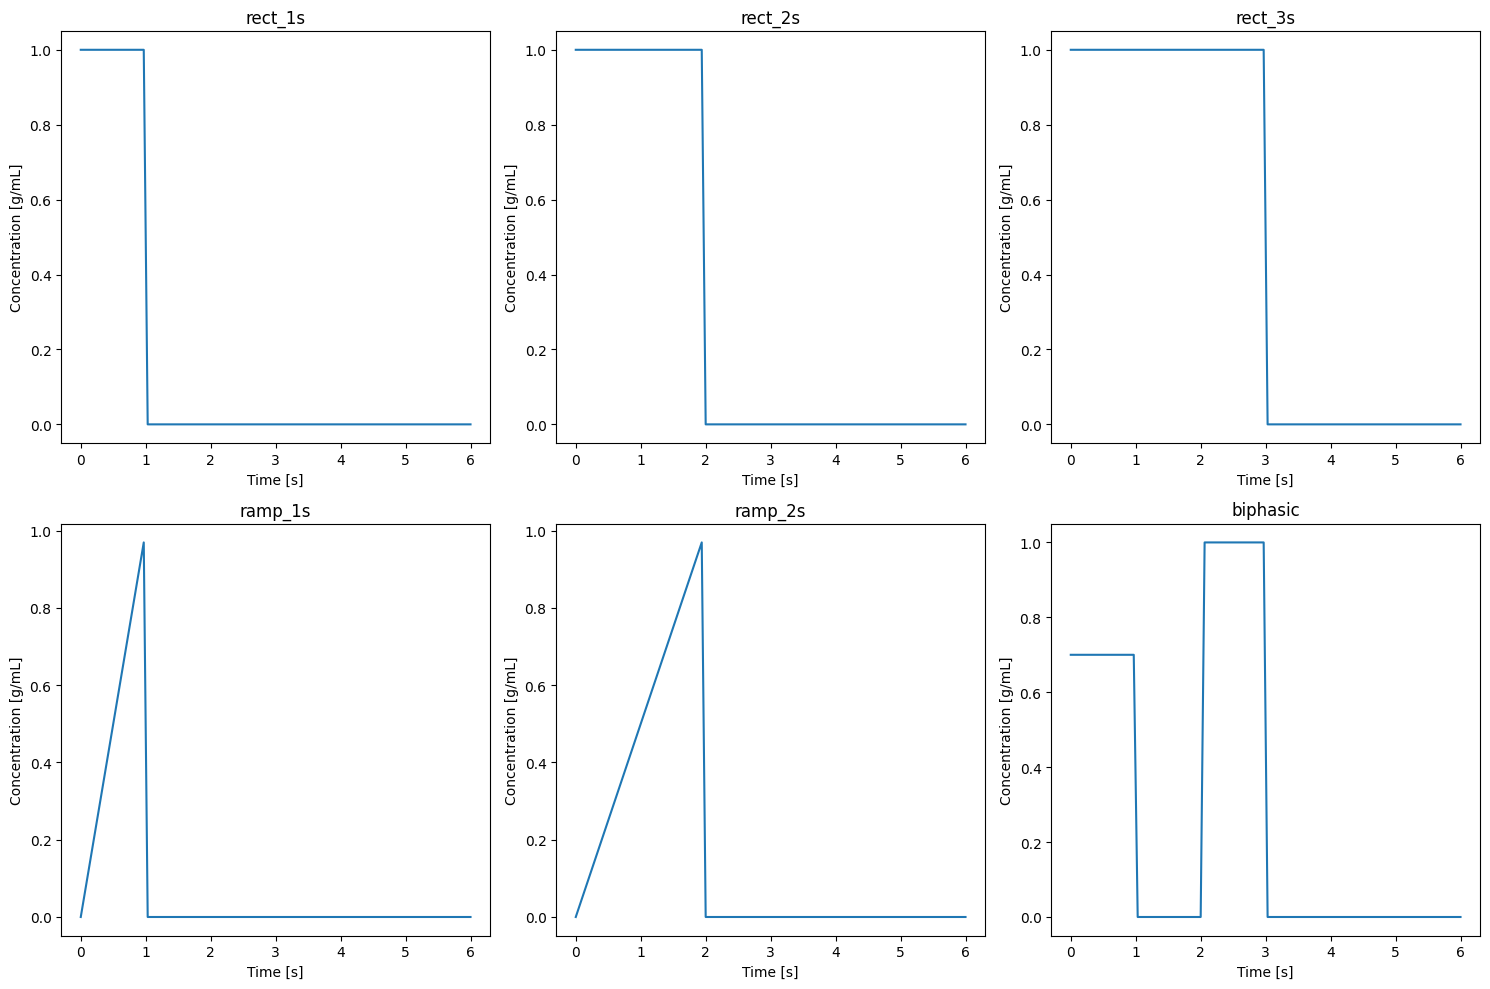

In [8]:
#Intializing time axis and injection protocols to plot
t = np.linspace(0, 6, 100)
inj_pros = [rect_1s, rect_2s, rect_3s, ramp_1s, ramp_2s, biphasic]

plt.figure(figsize=(15, 10))

#Plotting
for i, inj_pro in enumerate(inj_pros):
    plt.subplot(2, 3, i + 1)
    plt.plot(t, inj_pro(t))
    plt.xlabel('Time [s]')
    plt.ylabel('Concentration [g/mL]')
    plt.title(inj_pro.__name__)

plt.tight_layout()
plt.show()


All the plotted injection protocols match figure $5$ in the assignment, confirming that they have been implemented correctly.  

## Part 3

In exercise $1$ part $2$, we created three separate functions for the mass conservation equations, each with a hard-coded number of tanks. For this part, we need a more general implementation that allows the number of tanks to be specified by the user. We have therefore developed an improved function that takes $n$ as a parameter to define the number of tanks. Additionally, the function now allows the user to select the desired injection protocol, a feature that will be useful in later part of the assignment.

In [9]:
@njit
def cd_n(r, t, n_tanks, tau, inj_pro = rect_1s):
    '''
    Generic n-tank mass conservation model

    Parameters
    ----------
    r : array
        Current concentrations in each tank.
    t : float
        Current time.
    n_tanks : int
        Number of tanks in the system.
    tau : float
        Constant (V_tot / q).
    inj_pro : function, optional
        Injection protocol function (default: rect_1s).

    Returns
    ----------
    rp : array
        Time derivatived (dC/dt) for each tank.
    '''

    c_in = inj_pro(t)
    rp = np.zeros(n_tanks)

    for i in range(n_tanks):
        if i == 0:
            rp[0] =  (n_tanks/tau) * (c_in- r[i])
        else:
            rp[i] =  (n_tanks/tau) * (r[i - 1] - r[i])
    return rp

To find the "best match" of $V_{tot}$ we have chosen the more demanding approach, where the goal is to minimize the **Sum of Squared Residuals (SSR)**. This is done using one of the minimization algorithms discussed in class to identify the value of $V_{tot} that provides the best fit between the model output and the CFD data.

In [10]:
#Number of tanks, this is adjusted manually
n_tanks = 52

#Initial conditions
r0 = np.zeros(n_tanks)

#Import data
data = pd.read_csv('Data/Healthy_rect_1s.csv')
t_data = data['Time'].to_numpy()
c_data = data['Concentration'].to_numpy()

#Calculate Sum of Squared Residuals (SSR)
def ssr(tau):
    solver = ODESolver(f=cd_n, t0=0, tf=5, h=1e-3, r0=r0,
                   method='fast_rk4', adaptive=False,
                   args=(n_tanks, tau))
    t_model, c_model = solver.solve()
    c_out = np.interp(t_data, t_model, c_model[:, -1])
    return np.sum((c_data - c_out) ** 2)

#Derivative of SSR
def d_ssr(tau, delta_tau = 1e-3):
    return (ssr(tau + delta_tau) - ssr(tau)) / (2*delta_tau)


With both the SSR and its derivative implemented, we "cheat" a little to get an indication of which value of $\tau$ gives the smallest SSR. Although our main goal is to determine $V_{tot}$, we focus on finding $\tau$ since it is directly related through $\tau = \frac{V_{tot}}{q}$, and the flow rate $q$ is already known. Depending on the minimization algorithm used, the analysis provides a good starting point for an initial guess or a suitable search range for $\tau$. 

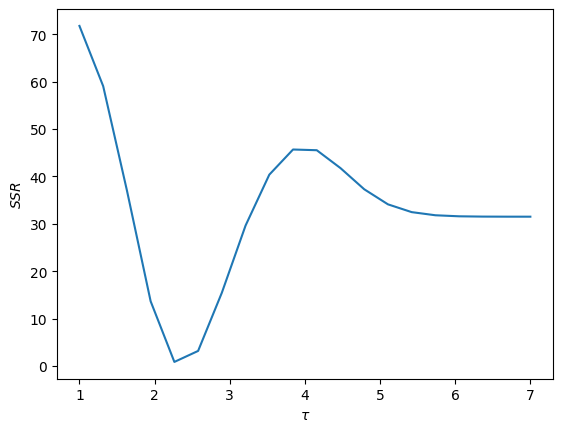

In [11]:
#Do not need a very fine grid
tau_values = np.linspace(1, 7, 20)

#List to store SSR-values
ssr_values = []

#Calculating SSR values based on tau
for tau in tau_values:
    ssr_values.append(ssr(tau))

#Plotting
plt.plot(tau_values, ssr_values)
plt.xlabel(r'$\tau$')
plt.ylabel('$SSR$')
plt.show()

When it came time to choose a minimization algorithm, we considered several options. We first tested the **bisection method**, as it is a safe and robust option. However, it turned out to be very slow, which is expected since it only converges linearly. Our implementation (not included in this report) took approximately $17$ seconds to find the minimum. This is acceptable, but far from ideal. 

To achieve faster convergence, we looked at **Newton's method**, which converges quadratically. Unfortunately, this approach requires the second derivative of the SSR, making it less practical in our case. Instead, the **secant method** (often referred to as the quasi-Newton method) provided a good balance between simplicity and speed. The secant method is similar to the Newton’s method but replaces the exact second derivative with a finite difference approximation. This avoids the need to manual differentiation while still achieving near-quadratic convergence, with the order of convergence equal to the golden ratio $\varphi \approx 1.618$ [\[$1$\]](#bib)[\[$4$\]](#bib)[\[$5$\]](#bib). 


In [12]:
def secant_method(fd, x0, x1, prec = 1e-8, max_iter = 20):
    '''
    Finds the root of a function f'(x) using the secant method

     Parameters
    ----------
    fd : function
        Function that returns f'(x), the derivative of the function whose
        root we are trying to find.
    x0 : float
        First initial guess.
    x1 : float
        Second initial guess.
    prec : float, optional
        Desired precision for convergence (default: 1e-8).
    max_iter : int, optional
        Maximum number of iterations (default: 20).
    '''
    fd0 = fd(x0)
    for i in range(1, max_iter):
        fd1 = fd(x1)
        ratio = (x1 - x0) / (fd1 - fd0)
        x2 = x1 - fd1 * ratio

        xdiff = abs(x2 - x1)
        x0, x1 = x1, x2
        fd0 = fd1

        if abs(xdiff / x2) < prec:
            break
    else:
        #Returns None if convergence not reached
        x2 = None

    return x2, i

The **secant_method** function is inspired by a script from [\[$6$\]](#bib), but has been  slightly modified to fit our implementation.

In [13]:
best_tau, iter = secant_method(fd = d_ssr, x0 = 1, x1 = 3, prec = 1e-8, max_iter = 100)
print(f'Found τ = {best_tau:.2f} after {iter} iterations')
print(f'With τ = {best_tau:.2f} we get d(ssr)/dτ = {d_ssr(best_tau):.2f}')

Found τ = 2.36 after 7 iterations
With τ = 2.36 we get d(ssr)/dτ = 0.00


After $7$ iterations, we find that $\tau = 2.36$ gives the minimum SSR value. The next step is to determine the number of tanks $n$ that provides the best fit. This is done by testing different values of $n$ and visually comparing the result through plots. 

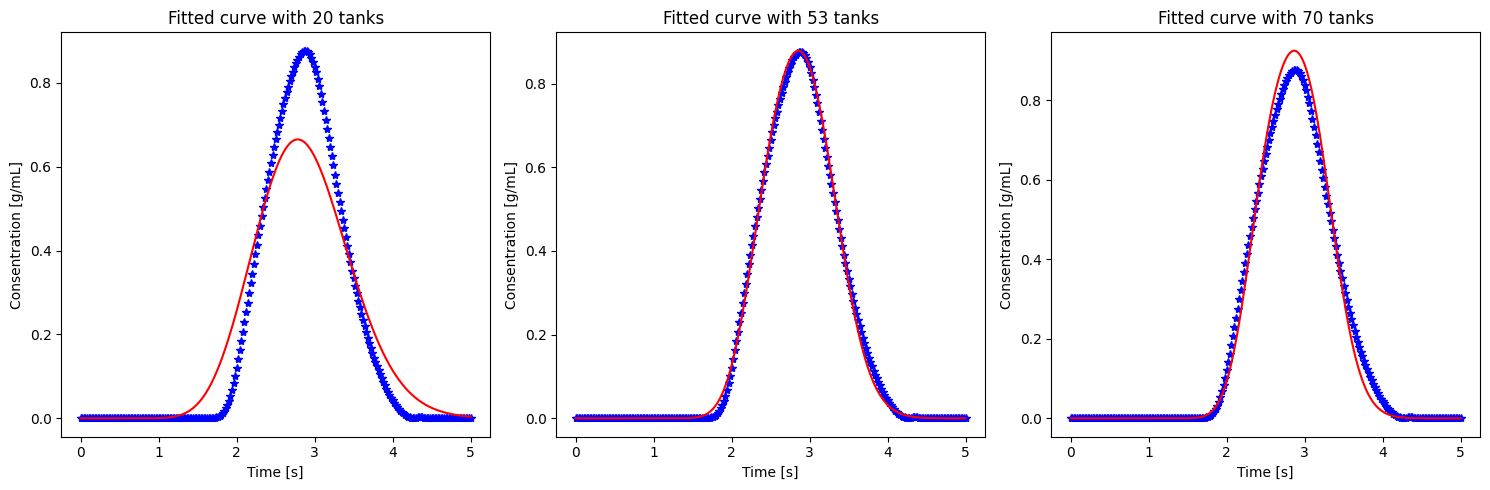

In [14]:
#Testing different number of tanks
n_tanks = [20, 53, 70]

plt.figure(figsize=(15, 5))
for i, tanks in enumerate(n_tanks):

    #Inital condition
    r0 = np.zeros(tanks)

    #Solve mass conservation equation for different number of tanks
    solver = ODESolver(f=cd_n, t0=0, tf=5, h=1e-3, r0=r0,
                    method='fast_rk4', adaptive=False, args=(tanks, best_tau))
    t_model, c_model = solver.solve()

    #Plotting
    plt.subplot(1, 3, i + 1)
    plt.plot(t_data, c_data, '*', color = 'blue')
    plt.plot(t_model, c_model[:,-1],'-', color = 'red')
    plt.xlabel('Time [s]')
    plt.ylabel('Consentration [g/mL]')
    plt.title(f'Fitted curve with {tanks} tanks')

plt.tight_layout()
plt.show()


From the plots above, it is evident that the best fit to the CFD data is obtained with $n = 53$ tanks. The value of $n$ gives the closest match between the model and the data. 

With this result, we can estimate the total aortic volume by combining the previously found values $\tau = 2.36 s$ and $q = 5 L/min$ using the relation $V_{tot} = q \cdot \tau$.

In [15]:
#Calculating V_tot in mL
v_tot = best_tau * q *(100/6)
print(f"The 'best match' V_tot is {v_tot:.2f}mL with τ = {best_tau:.2f}s and q = {q:.2f}L/min")

The 'best match' V_tot is 197.28mL with τ = 2.36s and q = 5.01L/min


Since we are not medical students, a quick Google search was performed to check whether our results are physically reasonable. We found that the median aortic volume is approximately $194mL$, so our result is at least within a physically plausible [\[$7$\]](#bib). 

## Part 4

In the previous part, we used the **rect 1s** injection protocol to tune our model. In this part, we keep the values of $V_{tot}$ and $n$ fixed to evaluate how well the model can predict the outlet concentration for other injection protocols.

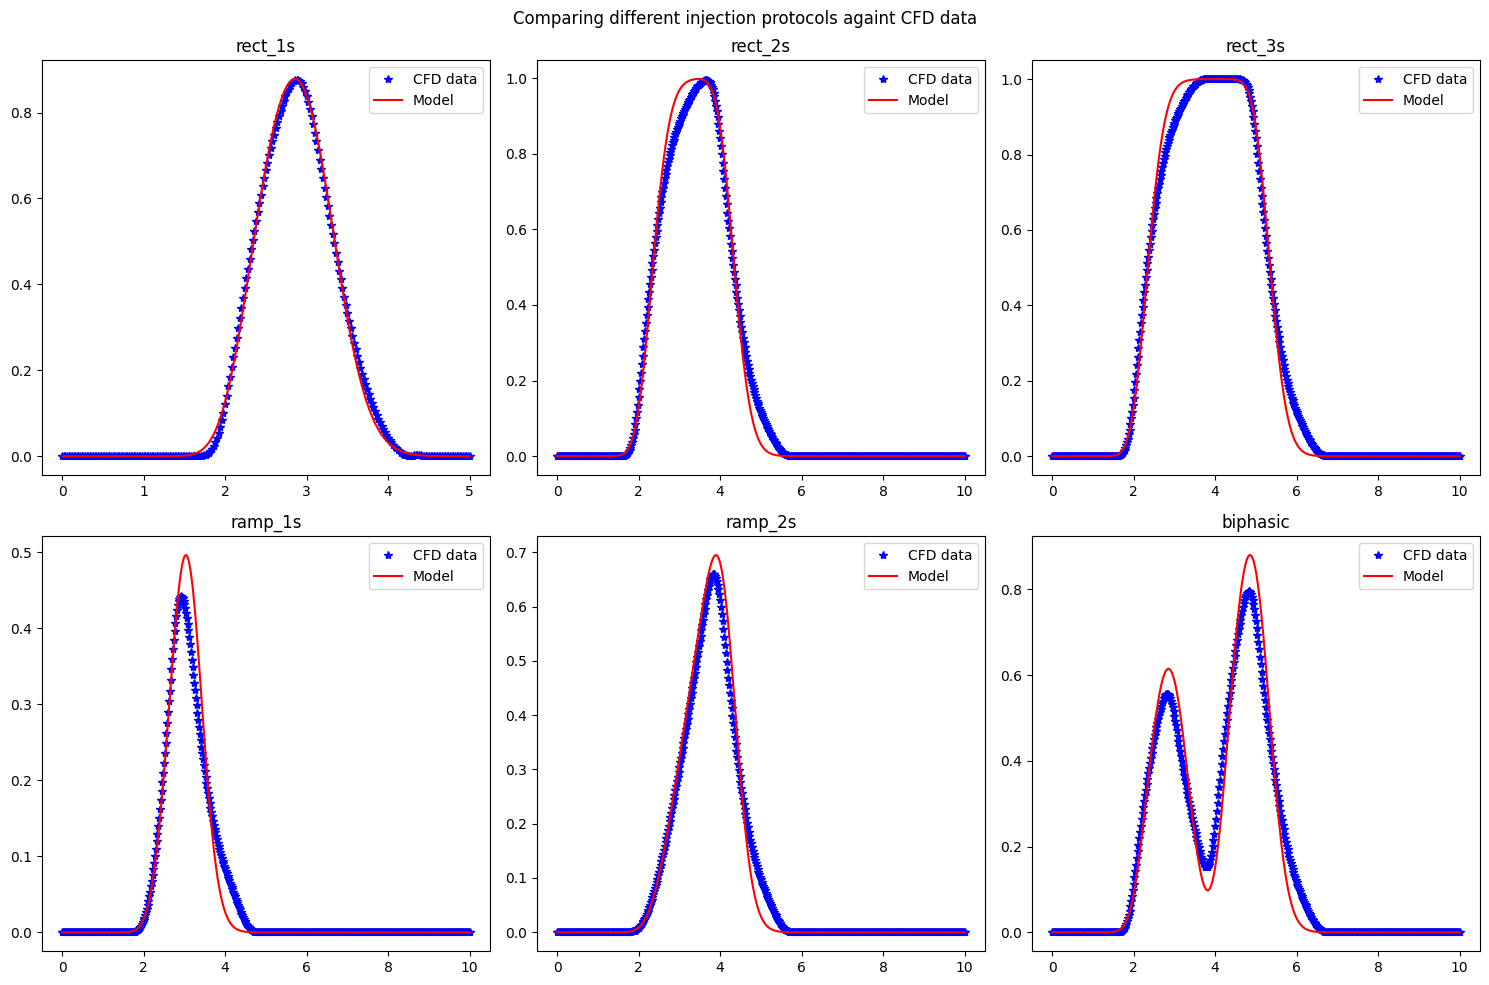

In [16]:
#Fixed model parameters
n_tanks = 53
r0 = np.zeros(n_tanks)
tau = best_tau.copy()

#Injection protocols to test
inj_pros = [rect_1s, rect_2s, rect_3s, ramp_1s, ramp_2s, biphasic]

#Labels for plotting
cdf_label = 'CFD data'
model_label = 'Model'

plt.figure(figsize=(15, 10))

for i, inj_pro in enumerate(inj_pros):

    #Injection protocal name as string
    inj_pro_str = inj_pro.__name__

    #Only rect_1s has time range [0-5], others use [0-10]
    if i > 0:
        tf = 10
    else:
        tf = 5

    #Numerical model
    solver= ODESolver(f=cd_n, t0=0, tf=tf, h=1e-2, r0=r0,
                   method='fast_rk4', adaptive=False, args=(n_tanks, tau, inj_pro))
    t_model, c_model = solver.solve()

    #CFD data
    data = pd.read_csv(f'Data/Healthy_{inj_pro_str}.csv')
    t_data = data['Time'].to_numpy()
    c_data = data['Concentration'].to_numpy()

    #Plotting
    plt.subplot(2, 3, i + 1)
    plt.plot(t_data, c_data, '*', color = 'blue', label = cdf_label)
    plt.plot(t_model, c_model[:, -1],'-', color = 'red', label = model_label )
    plt.title(inj_pro_str)
    plt.legend()

plt.suptitle('Comparing different injection protocols againt CFD data')
plt.tight_layout()
plt.show()


The results show that the model fits well for all injection protocols. For the **rect** protocols the model captures the main peak position and overall shape very accurately, only minor deviations in the peak height and decline regions. For the **ramp** and **biphasic** protocols, the model tends to overestimate the peak values and shows some discrepancies during the declining phase, indicating that the simplified tank model struggles with more complex injection protocols. 

# Exercise 3: Fit CSTR model to CFD model: Aorta with aneurysm

In this exercise, we apply the same modeling approach used in Exercise $2$ to a patient with an aortic aneurysm. The goal is to investigate how the fitted model parameters such as number of tanks, $\tau$, and total volume $V_{tot}$, differ from the healthy case. By comparing the model results and CFD data, we can examine how aneurysm affects the systems overall dynamics. 

## Part 1

For the case of an unhealthy patient, we repeat Exercise $2$ part $3$, but now using the aneurysm data. This requires modifying the SSR function so that it computes the sum of squared residuals based on the aneurysm dataset instead of the healthy case. 

In [17]:
#Number of tanks, this is adjusted manually
n_tanks = 20

#Initial conditions
r0 = np.zeros(n_tanks)

#Importing dataset
data_a = pd.read_csv('Data/Aneurysm_rect_1s.csv')
t_data_a = data_a['Time'].to_numpy()
c_data_a = data_a['Concentration'].to_numpy()

#Calculate Sum of Squared Residuals (SSR)
def ssr(tau):
    solver = ODESolver(f=cd_n, t0=0, tf=5, h=1e-3, r0=r0,
                   method='fast_rk4', adaptive=False,
                   args=(n_tanks, tau))
    t_model_a, c_model_a = solver.solve()
    c_out_a = np.interp(t_data_a, t_model_a, c_model_a[:, -1])
    return np.sum((c_data_a - c_out_a) ** 2)

As before, we plot the SSR for different values of $\tau$ to get an initial indication of the range where the minimum is likely to occur.  

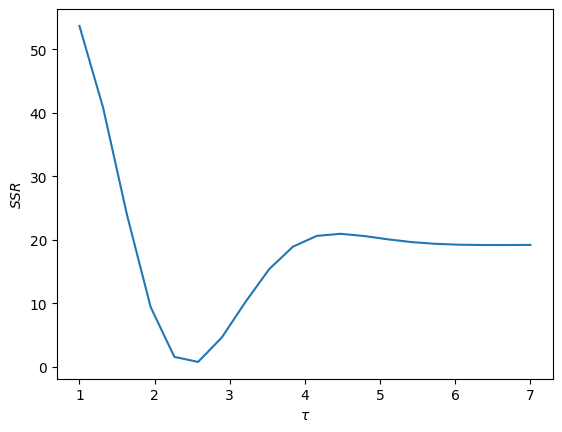

In [18]:
#Do not need a very fine grid
tau_values = np.linspace(1, 7, 20)
ssr_values = []

#Calculating SSR values based on tau
for tau in tau_values:
    ssr_values.append(ssr(tau))

#Plotting
plt.plot(tau_values, ssr_values)
plt.xlabel(r'$\tau$')
plt.ylabel('$SSR$')
plt.show()

From the plot, we can see that the optimal $\tau$, the value that gives the lowest SSR, appears to lie between $2$ and $3$.

In [19]:
best_tau_a, iter = secant_method(fd = d_ssr, x0 = 1, x1 = 3, prec = 1e-8, max_iter = 100)
print(f'Found τ = {best_tau_a:.2f} after {iter} iterations')
print(f'With τ = {best_tau_a:.2f} we get d(ssr)/dτ = {d_ssr(best_tau_a):.2f}')
ssr_exercise3 = ssr(best_tau_a) #Stored for later

Found τ = 2.46 after 7 iterations
With τ = 2.46 we get d(ssr)/dτ = -0.00


After $7$ iterations, the secant methods converges to $\tau = 2.36$.

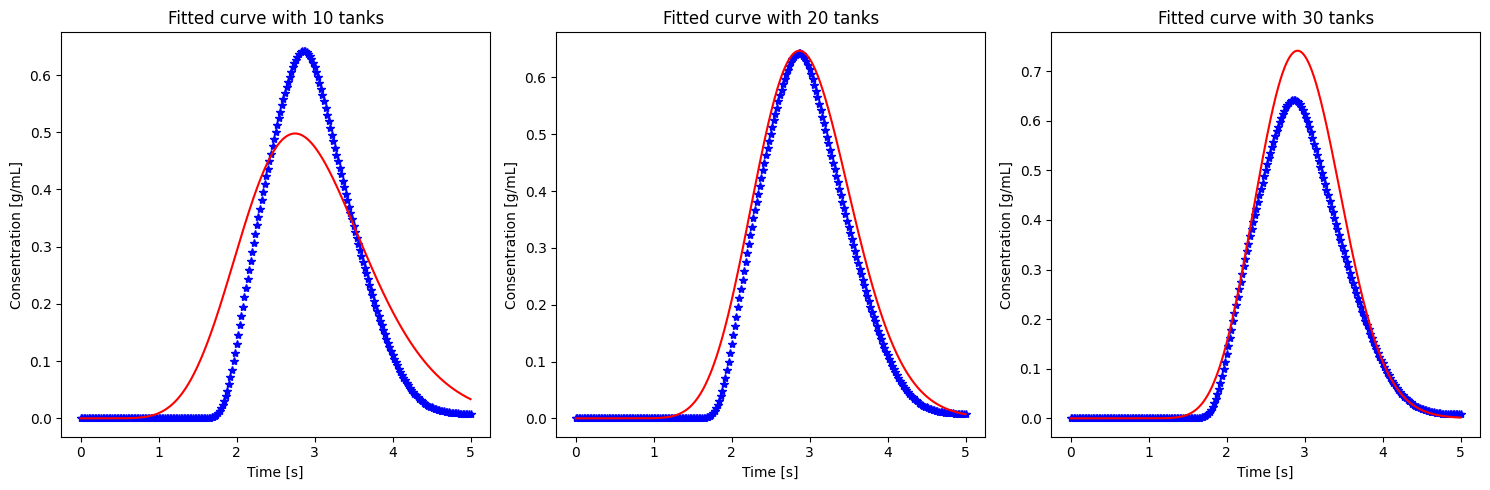

In [20]:
#Testing different number of tanks
n_tanks = [10, 20, 30]

plt.figure(figsize=(15, 5))

for i, tanks in enumerate(n_tanks):

    #Inital condition
    r0 = np.zeros(tanks)

    #Solve mass conservation equation for different number of tanks
    solver = ODESolver(f=cd_n, t0=0, tf=5, h=1e-3, r0=r0,
                    method='fast_rk4', adaptive=False, args=(tanks, best_tau_a))
    t_model_a, c_model_a = solver.solve()

    #Plotting
    plt.subplot(1, 3, i + 1)
    plt.plot(t_data_a, c_data_a, '*', color = 'blue')
    plt.plot(t_model_a, c_model_a[:,-1],'-', color = 'red')
    plt.xlabel('Time [s]')
    plt.ylabel('Consentration [g/mL]')
    plt.title(f'Fitted curve with {tanks} tanks')

plt.tight_layout()
plt.show()

The plots above show how well the model matches the data for different values of $n$. 

The number of tanks $n$ was adjusted manually, and the best fit was obtained with $n = 20$. The model captures the overall shape of the curve well, with only minor deviations during the rising and falling phases.

We have already derived the expression for the total aortic volume in Exercise $2$. Using the same relation $V_{tot} = \tau \cdot q \cdot \frac{100}{6}$, we can now calculate the volume for the aneurysm case based on the newly obtained value of $\tau$.

In [21]:
v_tot_a = best_tau_a * q *(100/6)
print(f"The 'best match' V_tot is {v_tot_a:.2f}mL with τ = {best_tau_a:.2f}s and q = {q:.2f}L/min")

The 'best match' V_tot is 204.95mL with τ = 2.46s and q = 5.01L/min


With this, we obtain a total volume of $V_{tot} = 204.95 mL$, which is slightly higher than in the healthy case, as expected for an aorta affected by an aneurysm. 

## Part 2

Similarly, we now repeat exercise $2$ part $4$, for the patient with an aneurysm. In this case, results for the healthy and aneurysm models are plotted side by side for a direct comparison.

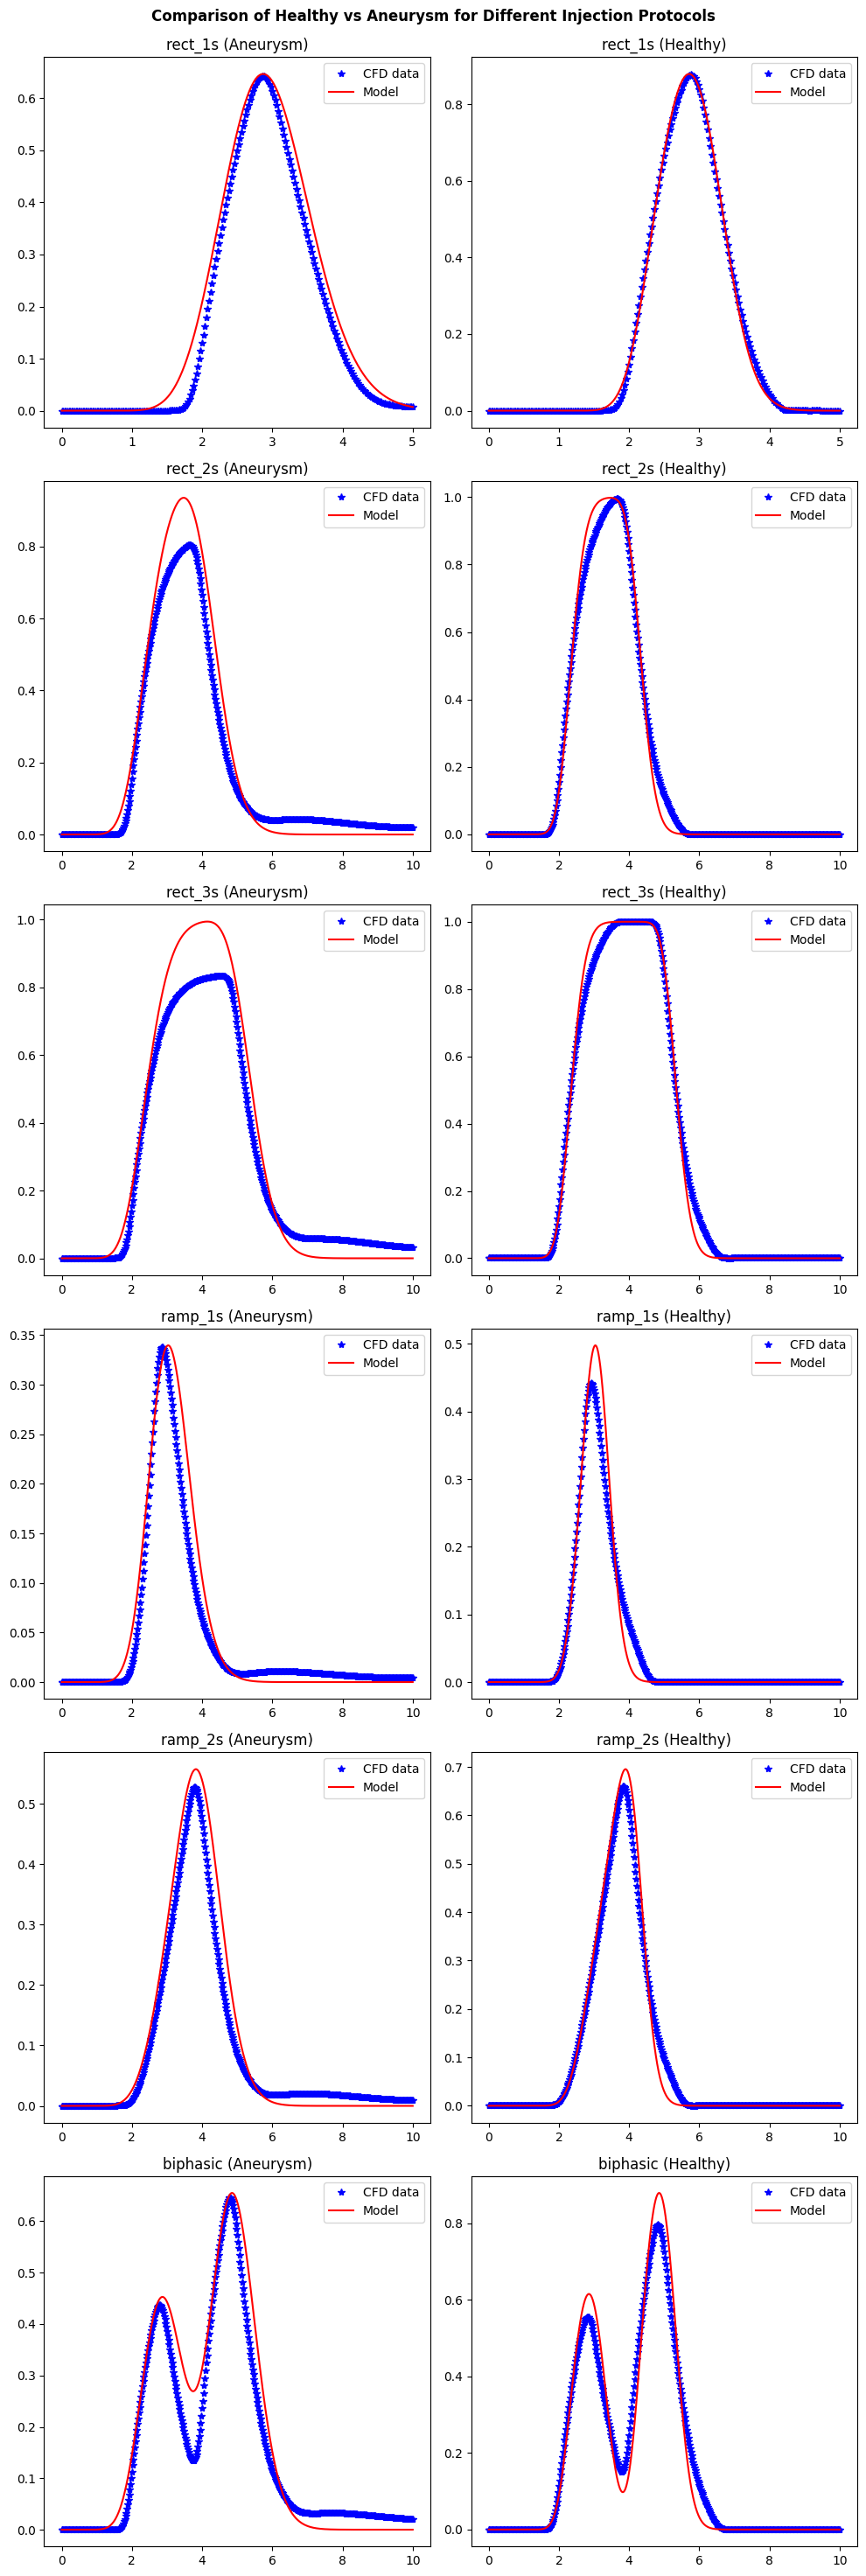

In [22]:
#Fixed parameters
labels = ['Aneurysm', 'Healthy']
n_tanks_list = [20, 53]
taus = [best_tau_a, best_tau]
r0_list = [np.zeros(n) for n in (n_tanks_list)]

inj_pros = [rect_1s, rect_2s, rect_3s, ramp_1s, ramp_2s, biphasic]

#Labels for plot
cdf_label = 'CFD data'
model_label = 'Model'

plt.figure(figsize=(10, 30))

for i, inj_pro in enumerate(inj_pros):

    #Injection protocal name as a string
    inj_pro_str = inj_pro_str = inj_pro.__name__

    #Only rect_1s has time range [0-5], others use [0-10]
    if inj_pro_str == 'rect_1s':
        tf = 5
    else:
        tf = 10

    for j, (n_tanks, tau, label) in enumerate(zip(n_tanks_list, taus, labels)):

        #Numerical model
        solver= ODESolver(f=cd_n, t0=0, tf=tf, h=1e-3, r0=r0_list[j],
                    method='fast_rk4', adaptive=False, args=(n_tanks, tau, inj_pro))
        t_model, c_model = solver.solve()

        #Getting data
        data = pd.read_csv(f'Data/{label}_{inj_pro_str}.csv')
        t_data = data['Time'].to_numpy()
        c_data = data['Concentration'].to_numpy()

        #Plotting
        plt.subplot(len(inj_pros), 2, 2 * i + j + 1)
        plt.plot(t_data, c_data, '*', color = 'blue', label = cdf_label)
        plt.plot(t_model, c_model[:, -1],'-', color = 'red', label = model_label )
        plt.title(f'{inj_pro_str} ({label})')
        plt.legend()

plt.suptitle('Comparison of Healthy vs Aneurysm for Different Injection Protocols', fontweight = 'bold')
plt.tight_layout(rect=[0, 0, 1, 0.985]) #Leave room for title
plt.show()

The aneurysm and healthy models show some distinct differences. For the **rect 2s** and **rect 3s**, the model overshoots the CFD data, especially near the peaks. The **ramp** protocols are quite similar between the two models, although the healthy case slightly overshoots the **ramp 1s** peak. In the **biphasic** protocol, the healthy model overestimates both peaks but underestimates the lower region between them, while the aneurysm model captures the main peaks well but misses the smaller, lower peak. Overall, both models follow the general trends, with minor deviations depending on the injection profile. 

## Part 3

The number of compartments was quite different between the two cases. For the healthy model, the best fit was obtained with $n = 53$ tanks, while the aneurysm model required only $n = 20$. From a modeling perspective, this indicates that the healthy case has a more complex flow pattern that needs to be represented by a larger number of smaller, well-mixed compartments. In contrast, the aneurysm behaves more like a single, larger, and more slowly mixed volume, which can be captured with fewer tanks. The lower $n$ value for the aneurysm therefore reflects slower mixing and the tracer staying in the system for a longer period. 

## Part 4 

The CSTR approach is simple and effcient, capturing main tracer dynamics with only a few parameters. It provides useful estimates but assumes perfect mixing, which limits accuracy for complex flows. The exercise showed how parameters like $n$ and $\tau$ affect the results and how simple models can still give meaningful insights [\[$1$\]](#bib).

# Exercise 4 (OPTIONAL): Extend model

In this exercise, the $n$-tank model is extended with an additional compartment representing the aneurysm. The goal is to see if this added exchange term improves the model fit compared to the simpler model from Exercise $3$.

## Part 1

To include the aneurysm compartment, we extend our $n$-tanks model by adding equation $(8)$. 

In [23]:
def new_cd_n(r, t, n_tanks, q, v_tot, d, v_a, inj_pro = rect_1s):
    c_in = inj_pro(t)
    rp = np.zeros(n_tanks + 1, float)
    v = v_tot / n_tanks

    C = r[: n_tanks]
    C_a = r[n_tanks]

    #Main tanks
    for i in range(n_tanks):
        if i == 0:
            rp[i] =  (q / v) * (c_in- C[i])
        else:
            rp[i] =  (q / v) * (C[i - 1] - C[i])
        if(i == n_tanks - 1):
            rp[i] -= (d / v) * (C[i] - C_a) #Eq 8, first line

    #Additional tank for aneurysm
    rp[n_tanks] = (d / v_a) * (C[n_tanks - 1] - C_a) #Eq 8, 2nd line

    return rp

Now we can compare the updated model with aneurysm exchange (new model) to the original $n-tank$ model from Exercise 3.  

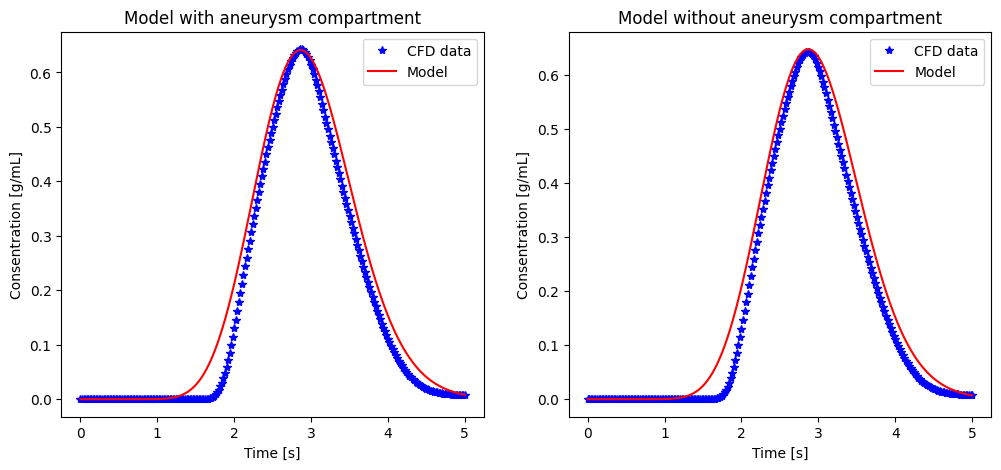

In [24]:
#Same parameters a Exercise 3
n_tanks = 20
r0 = np.zeros(n_tanks + 1, float)
v_a = v_tot_a - v_tot #mL
q = q * (100 / 6) #mL/s

#Recommended first guess
d = 10 * q #mL/s

#Import Aneurysm data
data_a = pd.read_csv('Data/Aneurysm_rect_1s.csv')
t_data_a = data_a['Time'].to_numpy()
c_data_a = data_a['Concentration'].to_numpy()

#Numerical model with added aneurysm compartment
solver_new = ODESolver(f=new_cd_n, t0=0, tf=5, h=1e-3, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, q, v_tot, d, v_a))
new_t_model, new_c_model = solver_new.solve()

#Numerical model without aneurysm compartment
solver_old = ODESolver(f=cd_n, t0=0, tf=5, h=1e-3, r0=r0[:-1],
                   method='fast_rk4', adaptive=False, args=(n_tanks, best_tau_a, rect_1s))
old_t_model, old_c_model = solver_old.solve()

#Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_data_a, c_data_a, '*', color = 'blue', label ='CFD data')
plt.plot(new_t_model, new_c_model[:, n_tanks - 1],'-', color = 'red', label = 'Model')
plt.title('Model with aneurysm compartment')
plt.xlabel('Time [s]')
plt.ylabel('Consentration [g/mL]')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t_data_a, c_data_a, '*', color = 'blue', label ='CFD data')
plt.plot(old_t_model, old_c_model[:, -1],'-', color = 'red', label = 'Model')
plt.title('Model without aneurysm compartment')
plt.xlabel('Time [s]')
plt.ylabel('Consentration [g/mL]')
plt.legend()
plt.show()

From the plots above, there is practically no difference between the model with the aneurysm compartment and the original model without it. Next, we use  SciPys **curve_fit** function to see if we can achieve a better fit. 

In [25]:
from scipy.optimize import curve_fit
import numpy as np

def model_output(t, d, v_a):
    ''' Return model outlet concentration for given d and v_a values '''
    r0 = np.zeros(n_tanks + 1, float)
    solver = ODESolver(
        f=new_cd_n, t0=0, tf=5, h=1e-3, r0=r0,
        method='rk4', adaptive=True,
        args=(n_tanks, q, v_tot, d, v_a)
    )
    t_model, c_model = solver.solve()
    c_out = np.interp(t, t_model, c_model[:, n_tanks - 1])
    return c_out

#Initial guess
d_guess = q * 10 #mL/s
v_a_guess = 10 #mL

#Fit model parameters (d, v_a) to CFD data
p0 = [d_guess, v_a_guess]
popt, pcov = curve_fit(
    model_output,
    t_data_a,
    c_data_a,
    p0=p0,
    bounds=([0, 0], [np.inf, np.inf])
)

#Print result
d_best, v_a_best = popt
print(f"Best fit: d = {d_best:.2f}mL/s, v_a = {v_a_best:.2f}mL")

Best fit: d = 955.91mL/s, v_a = 6.73mL


From the **curve_fit** function, we obtain the best-fit parameters $D = 955.91 mL/s$ and $V_a = 6.73mL$. Next, we plot the model to check whether these fitted parameters lead to any improvement in the overall fit. 

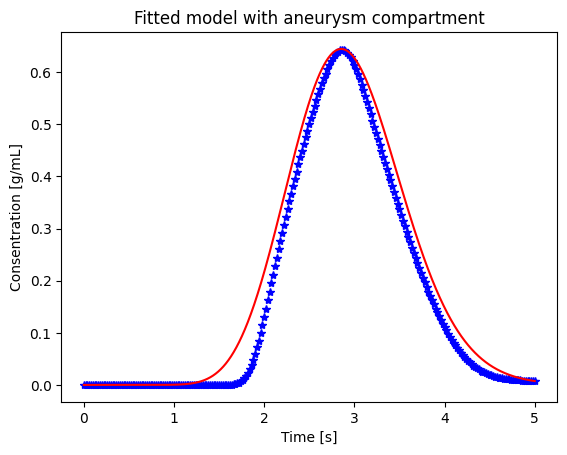

In [26]:
solver = ODESolver(
        f=new_cd_n, t0=0, tf=5, h=1e-3, r0=r0,
        method='rk4', adaptive=False,
        args=(n_tanks, q, v_tot, d_best, v_a_best)
    )
fitted_t_model, fitted_c_model = solver.solve()

plt.plot(t_data_a, c_data_a, '*', color = 'blue')
plt.plot(fitted_t_model, fitted_c_model[:, n_tanks - 1],'-', color = 'red')
plt.title('Fitted model with aneurysm compartment')
plt.xlabel('Time [s]')
plt.ylabel('Consentration [g/mL]')
plt.show()

At first glance, there does not appear to be any improvement in the overall fit. Before drawing a conclusion, we compare the SSR of the fitted model with that of the model from Exercise $3$.

In [27]:
#Calc ssr for fitted model
c_out_fitted  = np.interp(t_data_a, fitted_t_model, fitted_c_model[:, n_tanks - 1])
ssr_fitted = np.sum((c_data_a - c_out_fitted) ** 2)

print(f'SSR for fitted model: {ssr_fitted:.4f}')
print(f'SSR for Exercise 3 model: {ssr_exercise3:.4f}')

#Check which model has the best fit
if ssr_exercise3 < ssr_fitted:
    print(f'\nThe model from Exercise 3 has a better fit')
else:
    print(f'\nThe fitted model has a better fit')

print(f'The diffrence in SSR is: {abs(ssr_exercise3 - ssr_fitted):.4f}')

SSR for fitted model: 0.3854
SSR for Exercise 3 model: 0.3763

The model from Exercise 3 has a better fit
The diffrence in SSR is: 0.0091


This confirms that the fit has not improved, in fact, it is slightly worse. Therefore, adding the extra aneurysm compartment introduced in Exercise $4$ did not lead to a better fit to the CFD data. 

# Self-reflection
### Simen

### Nataliia

# Conclution

# Bibliography
<a id="bib"></a>

\[$1$] A. Hiorth, *Computational Engineering and Modeling*. [Online]. Available: https://github.com/ahiorth/CompEngineering. [Accessed: 05‑Nov‑2025].

\[$2$] NumPy Developers, “numpy.trapezoid — NumPy v2.3 Manual,” NumPy Documentation. [Online]. Available: https://numpy.org/doc/2.3/reference/generated/numpy.trapezoid.html. [Accessed: 5 Nov 2025].

\[$3$] NumPy Developers, “numpy.where — NumPy v2.2 Manual,” NumPy Documentation. [Online]. Available: [https://numpy.org/doc/2.2/reference/generated/numpy.where.html](https://numpy.org/doc/2.2/reference/generated/numpy.where.html). [Accessed: 5 Nov 2025].


\[$4$\] A. Gezerlis, *Numerical Methods in Physics with Python*, 2nd ed. Cambridge, UK: Cambridge University Press, 2023.

\[$5$\] “Secant method,” *Wikipedia, The Free Encyclopedia*. [Online]. Available: [https://en.wikipedia.org/wiki/Secant_method](https://en.wikipedia.org/wiki/Secant_method). [Accessed: 5 Nov 2025].


\[$6$\] M. Newman, *Computational Physics*. San Francisco, CA, USA: CreateSpace Independent Publishing Platform, 2013.

\[$7$\] Akohov A., et al., “Aortic volume determines global end-diastolic volume measured by transpulmonary thermodilution,” *Intensive Care Medicine Experimental*, vol. 8, no. 1, Jan. 2020. [Online]. Available: [https://pmc.ncbi.nlm.nih.gov/articles/PMC6940405/](https://pmc.ncbi.nlm.nih.gov/articles/PMC6940405/) .
